In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/sap_job_data.csv")

df.head()

,execution_id,job_id,job_name,job_type,scheduled_hour,day_of_week,start_delay_minutes,previous_success_count,previous_failure_count,average_runtime_minutes,expected_data_volume,cpu_usage_percent,memory_usage_percent,dependency_status,job_status
0,1,JOB016,WAREHOUSE_UPDATE,Synchronization,6,Monday,14,23,7,64,84041,82,35,Delayed,Failed
1,2,JOB007,CUSTOMER_REPORT,Backup,19,Tuesday,11,14,5,92,364669,82,51,Not Ready,Failed
2,3,JOB012,DATABASE_BACKUP,Data Processing,14,Saturday,3,27,1,119,9977,29,44,Ready,Success
3,4,JOB015,DAILY_ANALYTICS,Data Transfer,10,Sunday,29,8,5,106,380693,24,56,Ready,Success
4,5,JOB002,MONTHLY_PAYROLL,Backup,7,Tuesday,30,2,4,21,295737,72,56,Not Ready,Failed


In [19]:
df.shape

(10000, 15)

In [20]:
df.columns

Index(['execution_id', 'job_id', 'job_name', 'job_type', 'scheduled_hour',
       'day_of_week', 'start_delay_minutes', 'previous_success_count',
       'previous_failure_count', 'average_runtime_minutes',
       'expected_data_volume', 'cpu_usage_percent', 'memory_usage_percent',
       'dependency_status', 'job_status'],
      dtype='str')

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   execution_id             10000 non-null  int64
 1   job_id                   10000 non-null  str  
 2   job_name                 10000 non-null  str  
 3   job_type                 10000 non-null  str  
 4   scheduled_hour           10000 non-null  int64
 5   day_of_week              10000 non-null  str  
 6   start_delay_minutes      10000 non-null  int64
 7   previous_success_count   10000 non-null  int64
 8   previous_failure_count   10000 non-null  int64
 9   average_runtime_minutes  10000 non-null  int64
 10  expected_data_volume     10000 non-null  int64
 11  cpu_usage_percent        10000 non-null  int64
 12  memory_usage_percent     10000 non-null  int64
 13  dependency_status        10000 non-null  str  
 14  job_status               10000 non-null  str  
dtypes: int64(9), s

In [22]:
df["job_id"].nunique()

20

In [23]:
df.groupby("job_name")["job_status"].apply(
    lambda x: (x == "Failed").sum()
).sort_values(ascending=False)

job_name
INVOICE_PROCESSING    285
STOCK_UPDATE          274
LOG_CLEANUP           266
MASTER_DATA_SYNC      259
DAILY_SALES           256
DATABASE_BACKUP       252
DAILY_ANALYTICS       252
WAREHOUSE_UPDATE      250
FINANCE_REPORT        249
SALES_REPORT          248
DATA_TRANSFER         247
VENDOR_DATA_SYNC      244
INVENTORY_UPDATE      243
ARCHIVE_JOB           239
MONTHLY_PAYROLL       234
BACKUP_JOB            226
EMPLOYEE_DATA_SYNC    226
SYSTEM_MONITORING     225
ORDER_PROCESSING      222
CUSTOMER_REPORT       217
Name: job_status, dtype: int64

In [24]:
df.groupby("dependency_status")["job_status"].apply(
    lambda x: (x == "Failed").mean() * 100
).sort_values(ascending=False)

dependency_status
Not Ready    81.844946
Delayed      64.407606
Ready        39.812410
Name: job_status, dtype: float64

In [25]:
df.groupby("job_status")["cpu_usage_percent"].mean()

job_status
Failed     60.106838
Success    54.344868
Name: cpu_usage_percent, dtype: float64

In [26]:
df.groupby("job_status")["memory_usage_percent"].mean()

job_status
Failed     59.840456
Success    54.704090
Name: memory_usage_percent, dtype: float64

In [27]:
df.groupby("job_status")["previous_failure_count"].mean()

job_status
Failed     5.087709
Success    4.102045
Name: previous_failure_count, dtype: float64

In [28]:
df.groupby("job_status")["expected_data_volume"].mean()

job_status
Failed     265191.187220
Success    235396.764845
Name: expected_data_volume, dtype: float64

In [29]:
df.groupby("job_status")["start_delay_minutes"].mean()

job_status
Failed     15.938543
Success    13.932757
Name: start_delay_minutes, dtype: float64

<Axes: title={'center': 'Job Failure Rate by Dependency Status'}, xlabel='Dependency Status', ylabel='Failure Rate (%)'>

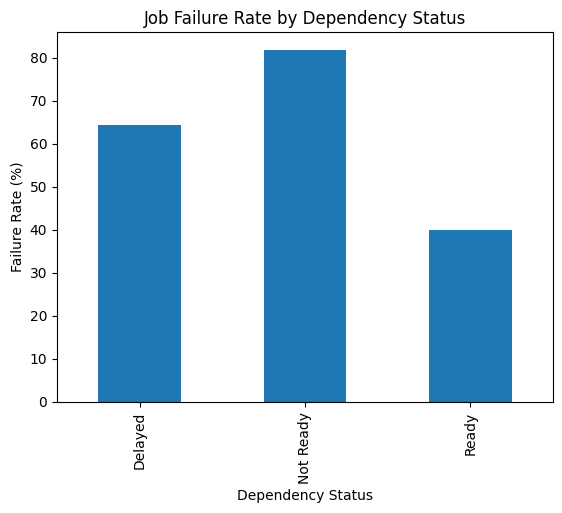

In [30]:
failure_rate = df.groupby("dependency_status")["job_status"].apply(
    lambda x: (x == "Failed").mean() * 100
)

failure_rate.plot(
    kind="bar",
    title="Job Failure Rate by Dependency Status",
    xlabel="Dependency Status",
    ylabel="Failure Rate (%)"
)

<Axes: title={'center': 'Number of Job Failures by Job'}, xlabel='Job Name', ylabel='Number of Failures'>

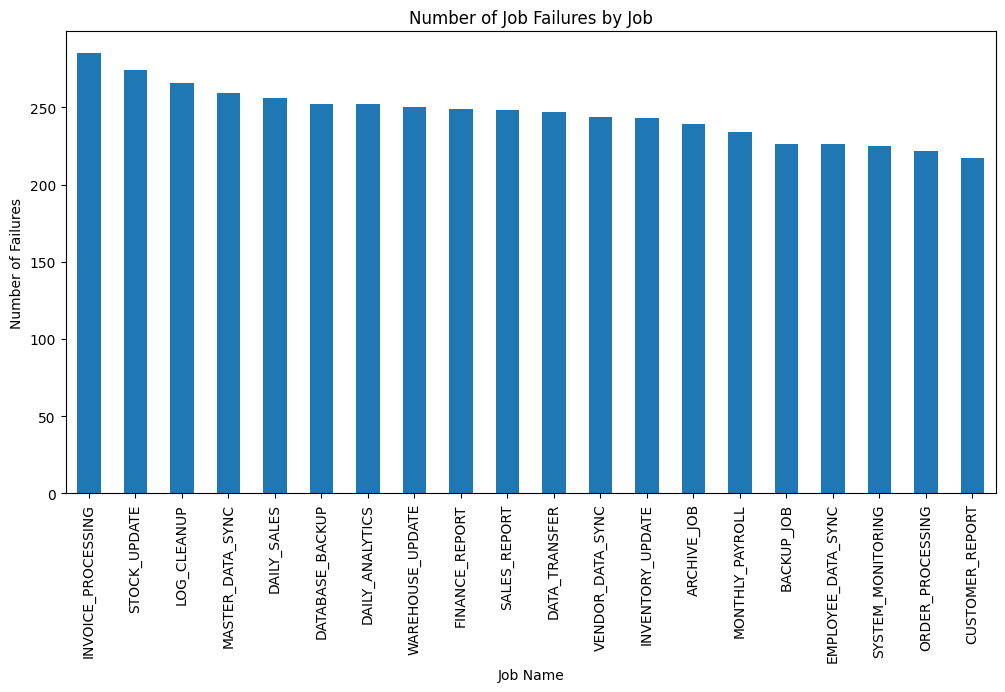

In [31]:
job_failures = df.groupby("job_name")["job_status"].apply(
    lambda x: (x == "Failed").sum()
).sort_values(ascending=False)

job_failures.plot(
    kind="bar",
    figsize=(12, 6),
    title="Number of Job Failures by Job",
    xlabel="Job Name",
    ylabel="Number of Failures"
)

In [32]:
df.groupby("job_status")["previous_failure_count"].mean()

job_status
Failed     5.087709
Success    4.102045
Name: previous_failure_count, dtype: float64

In [33]:
df.describe()

,execution_id,scheduled_hour,start_delay_minutes,previous_success_count,previous_failure_count,average_runtime_minutes,expected_data_volume,cpu_usage_percent,memory_usage_percent
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,11.609800,14.918400,14.534900,4.586400,62.077400,250037.744000,57.176300,57.228100
std,2886.89568,6.951257,8.885012,8.649616,2.855022,33.821946,144157.023842,21.973282,21.896758
min,1.00000,0.000000,0.000000,0.000000,0.000000,5.000000,1005.000000,20.000000,20.000000
25%,2500.75000,6.000000,7.000000,7.000000,2.000000,32.000000,125232.500000,38.000000,38.000000
50%,5000.50000,12.000000,15.000000,14.000000,5.000000,62.000000,251700.000000,57.000000,57.000000
75%,7500.25000,18.000000,23.000000,22.000000,7.000000,92.000000,374403.750000,76.000000,76.000000
max,10000.00000,23.000000,30.000000,29.000000,9.000000,120.000000,499981.000000,95.000000,95.000000


In [34]:
df["job_status"].value_counts()

job_status
Success    5086
Failed     4914
Name: count, dtype: int64

In [35]:
X = df.drop(columns=["job_status", "execution_id"])
y = df["job_status"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (10000, 13)
Target: (10000,)


In [36]:
X.select_dtypes(include="object").columns

C:\Users\debas\AppData\Local\Temp\ipykernel_36924\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['job_id', 'job_name', 'job_type', 'day_of_week', 'dependency_status'], dtype='str')

In [37]:
X.dtypes

job_id                       str
job_name                     str
job_type                     str
scheduled_hour             int64
day_of_week                  str
start_delay_minutes        int64
previous_success_count     int64
previous_failure_count     int64
average_runtime_minutes    int64
expected_data_volume       int64
cpu_usage_percent          int64
memory_usage_percent       int64
dependency_status            str
dtype: object

In [38]:
X = df.drop(columns=["job_status", "execution_id", "job_id"])

print("Features:", X.shape)

Features: (10000, 12)


In [39]:
categorical_features = X.select_dtypes(include="str").columns.tolist()
numeric_features = X.select_dtypes(include="number").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['job_name', 'job_type', 'day_of_week', 'dependency_status']

Numeric features:
['scheduled_hour', 'start_delay_minutes', 'previous_success_count', 'previous_failure_count', 'average_runtime_minutes', 'expected_data_volume', 'cpu_usage_percent', 'memory_usage_percent']


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 12)
Testing data: (2000, 12)


In [42]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (8000, 43)
Testing data after preprocessing: (2000, 43)


In [43]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_processed, y_train)

print("Model trained successfully")

Model trained successfully


In [44]:
y_pred = model.predict(X_test_processed)

print("Predictions created successfully")
print(y_pred[:10])

Predictions created successfully
['Success' 'Success' 'Success' 'Failed' 'Success' 'Failed' 'Failed'
 'Success' 'Failed' 'Success']


In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.678

Classification Report:
              precision    recall  f1-score   support

      Failed       0.69      0.63      0.66       983
     Success       0.67      0.72      0.70      1017

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.68      0.68      2000


Confusion Matrix:
[[621 362]
 [282 735]]


In [46]:
feature_importance = model.feature_importances_

print("Number of model features:", len(feature_importance))
print("Total importance:", feature_importance.sum())

Number of model features: 43
Total importance: 0.9999999999999998


In [48]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(10)

,feature,importance
41,num__cpu_usage_percent,0.097470
40,num__expected_data_volume,0.096114
42,num__memory_usage_percent,0.092388
39,num__average_runtime_minutes,0.090586
36,num__start_delay_minutes,0.077395
37,num__previous_success_count,0.069907
38,num__previous_failure_count,0.068988
35,num__scheduled_hour,0.065917
34,cat__dependency_status_Ready,0.043173
33,cat__dependency_status_Not Ready,0.028939


In [54]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

logistic_pred = logistic_model.predict(X_test_processed)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


c:\Users\debas\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create scaler
scaler = StandardScaler()

# Scale numeric features
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("Feature scaling completed")

Feature scaling completed


In [55]:
from sklearn.linear_model import LogisticRegression

logistic_model_scaled = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model_scaled.fit(X_train_scaled, y_train)

logistic_pred_scaled = logistic_model_scaled.predict(X_test_scaled)

print("Scaled Logistic Regression trained successfully")

Scaled Logistic Regression trained successfully


In [56]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logistic_accuracy = accuracy_score(y_test, logistic_pred_scaled)

print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, logistic_pred_scaled))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_pred_scaled))

Logistic Regression Accuracy: 0.6685

Classification Report:
              precision    recall  f1-score   support

      Failed       0.67      0.63      0.65       983
     Success       0.66      0.71      0.68      1017

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000


Confusion Matrix:
[[618 365]
 [298 719]]


In [57]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gradient_model.fit(X_train_processed, y_train)

gradient_pred = gradient_model.predict(X_test_processed)

print("Gradient Boosting trained successfully")

Gradient Boosting trained successfully


In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

gradient_accuracy = accuracy_score(y_test, gradient_pred)

print("Gradient Boosting Accuracy:", gradient_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, gradient_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, gradient_pred))

Gradient Boosting Accuracy: 0.681

Classification Report:
              precision    recall  f1-score   support

      Failed       0.70      0.62      0.66       983
     Success       0.67      0.74      0.70      1017

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.68      0.68      0.68      2000


Confusion Matrix:
[[611 372]
 [266 751]]


In [59]:
from sklearn.metrics import roc_auc_score

# Prediction probabilities
rf_prob = model.predict_proba(X_test_processed)[:, 1]
logistic_prob = logistic_model_scaled.predict_proba(X_test_scaled)[:, 1]
gradient_prob = gradient_model.predict_proba(X_test_processed)[:, 1]

# ROC-AUC scores
rf_auc = roc_auc_score(y_test, rf_prob)
logistic_auc = roc_auc_score(y_test, logistic_prob)
gradient_auc = roc_auc_score(y_test, gradient_prob)

print("Random Forest ROC-AUC:", rf_auc)
print("Logistic Regression ROC-AUC:", logistic_auc)
print("Gradient Boosting ROC-AUC:", gradient_auc)

Random Forest ROC-AUC: 0.7384649163608282
Logistic Regression ROC-AUC: 0.7421774892944062
Gradient Boosting ROC-AUC: 0.756535638799613


In [61]:
rf_accuracy = accuracy

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        gradient_accuracy
    ],
    "Failed Recall": [
        0.63,
        0.63,
        0.62
    ],
    "Failed F1": [
        0.65,
        0.66,
        0.66
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc,
        gradient_auc
    ]
})

model_comparison.sort_values(
    "ROC-AUC",
    ascending=False
)

model_comparison.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Failed Recall,Failed F1,ROC-AUC
2,Gradient Boosting,0.6810,0.62,0.66,0.756536
0,Logistic Regression,0.6685,0.63,0.65,0.742177
1,Random Forest,0.6780,0.63,0.66,0.738465


In [62]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained Gradient Boosting model
joblib.dump(
    gradient_model,
    "../models/gradient_boosting_model.pkl"
)

# Save preprocessing transformer
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Model and preprocessor saved successfully")

Model and preprocessor saved successfully
